
In this notebook, you will:
1. Train multiple Machine Learning models
2. Compare their performance
3. Build a Deep Learning model (ANN)
4. Compare ML vs DL
5. Save the best model
6. Prepare everything for deployment (Flask / Streamlit / Docker)


IMPORTANT:
You are NOT just running code — you are building a REAL project.

Take your time and read the comments carefully.
"""

# Section 1 :  Import & Load Data

In [1]:
# ─── Install any missing packages (run once) ───────────────────────────────
# !pip install xgboost imbalanced-learn -q

# ─── Standard libraries ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Sklearn ───────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ─── ML Models ─────────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from xgboost                 import XGBClassifier

# ─── Deep Learning ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ─── Save/Load Model ───────────────────────────────────────────────────────
import joblib
import pickle

print(' All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

 All libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# ─── Load Dataset ──────────────────────────────────────────────────────────
# sklearn has this dataset built-in — no download needed!
data = load_breast_cancer()

# check the data
#ه بيرجع object (حاجة شبه dictionary) فيها كل حاجة عن الداتا



data.keys()



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
# Convert to DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
# NOW ADD THE TARGET COLUM
df['target'] = data.target   # 0 = Malignant, 1 = Benign

In [35]:
#save the daata for latter
df.to_csv("breast_cancer.csv", index=False)

In [4]:
# ─── Quick Overview ────────────────────────────────────────────────────────

#chech the data set shape
print(' Dataset Shape:', df.shape)


 Dataset Shape: (569, 31)


In [8]:
#heck the first  5 rows
print('\n First 5 rows:')
print ( df.head())

#the last 10 rows
print(' The last 10 rows ')
print(df.tail(10))


 First 5 rows:
 The last 10 rows 
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
559        11.51         23.93           74.52      403.5          0.09261   
560        14.05         27.15           91.38      600.4          0.09929   
561        11.20         29.37           70.67      386.0          0.07449   
562        15.22         30.62          103.40      716.9          0.10480   
563        20.92         25.09          143.00     1347.0          0.10990   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
559           0.10210        

In [6]:
# Statistical summary _ u can use Transpose it will help
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [7]:
# get the missing values
print(f'  Missing values: {df.isnull().sum().sum()}')
print()


  Missing values: 0



##  Section 2 — Exploratory Data Analysis (EDA)

In [ ]:
# ─── Class Distribution ────────────────────────────────────────────────────
# Important to check: is data balanced?
# Count plot
sns.countplot(x='target', data=df, palette=['red', 'green'])
plt.title("Class Distribution")
plt.show()

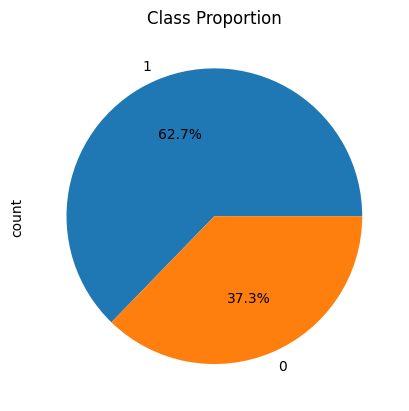

In [10]:
# Pie chart
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class Proportion")
plt.show()

In [46]:
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.627417
0,0.372583


In [ ]:
# can u put them togther side by side  ? ( hint  use subplot )

In [9]:
#get the columns names   and their  leng
print(df.columns)
print(len(df.columns))

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')
31


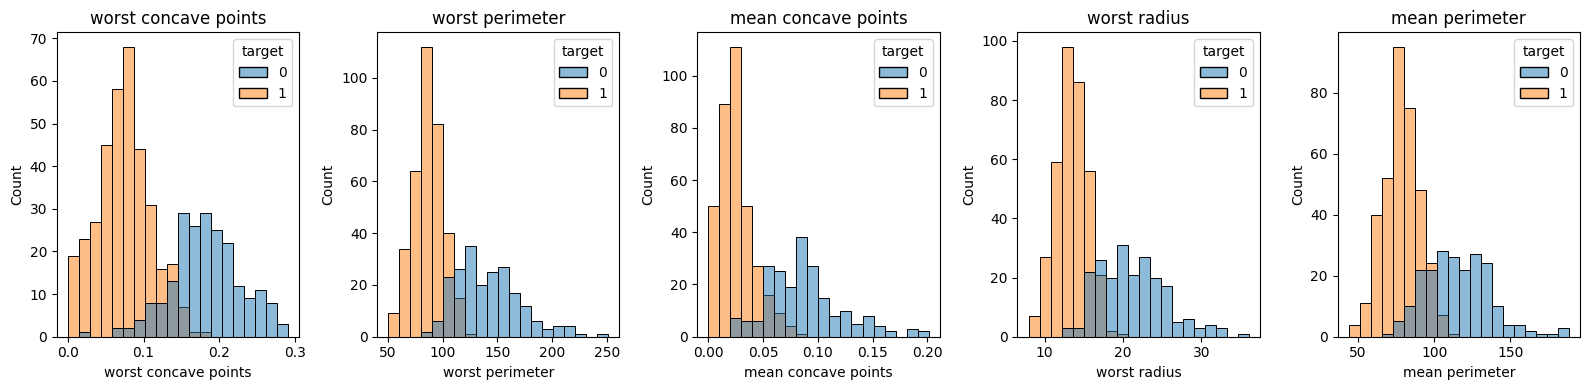

In [11]:
# ─── Feature Distributions ─────────────────────────────────────────────────
## get the most corelated features to ur target and show their distribution

#  get the correlation and sort it
corr = df.corr()['target'].abs().sort_values(ascending=False)

#  get top features (excluding target itself)
top_features = corr.index[1:6]

#  now plot them _ use subplot
fig, axes = plt.subplots(1, len(top_features), figsize=(16, 4))

#use a for loop to plot the most correlated featues
for i, f in enumerate(top_features):
    sns.histplot(data=df, x=f, hue='target', bins=20, ax=axes[i])
    axes[i].set_title(f)

plt.tight_layout()
plt.show()





لو التوزيعين بعيدين عن بعض:

يعني:

 الـ feature ده “بيفصل” بين الكلاسات كويس

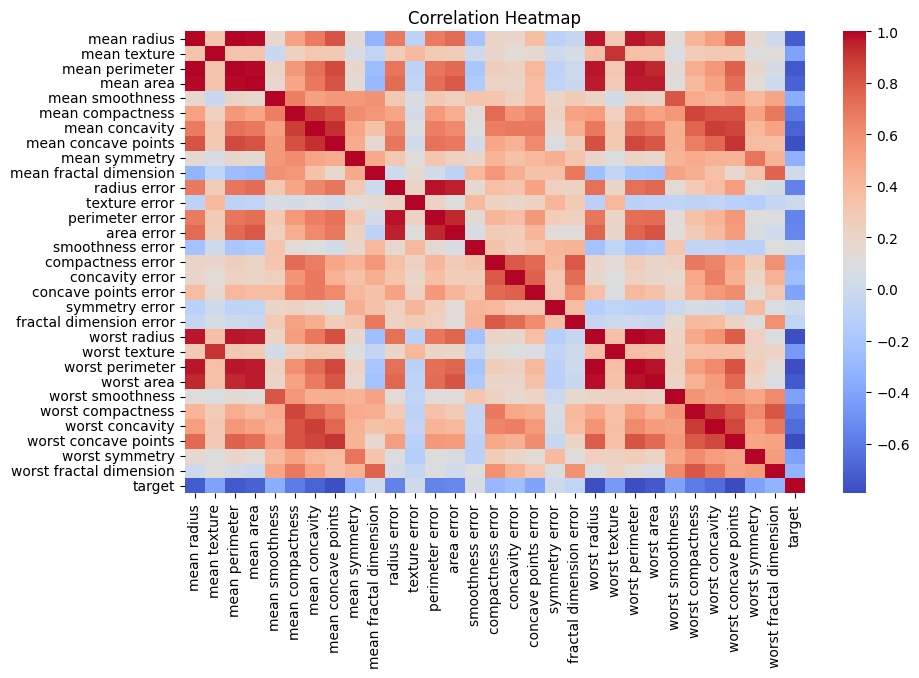

In [12]:
# ─── Correlation Heatmap ───────────────────────────────────────────────────
# Find highly correlated features
plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
# u can save the plot using  plt.savefig(imagetitle.png,dpi="resoultion",bbox_inches='tight'# to remove extra spaces )
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

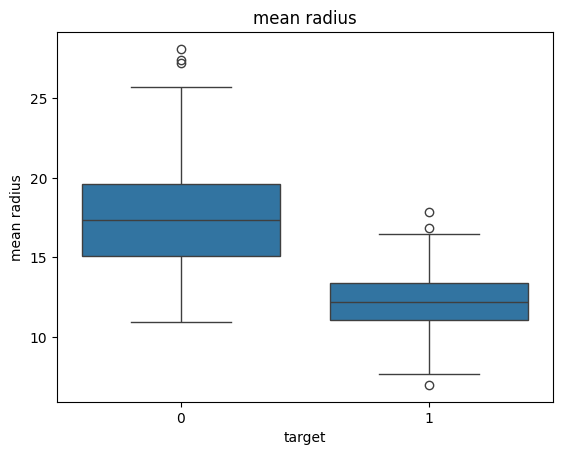

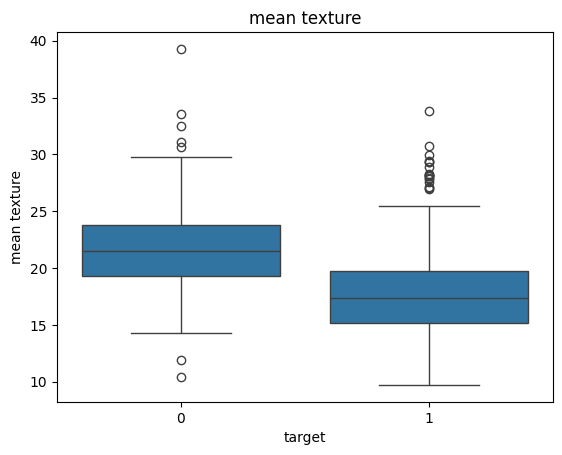

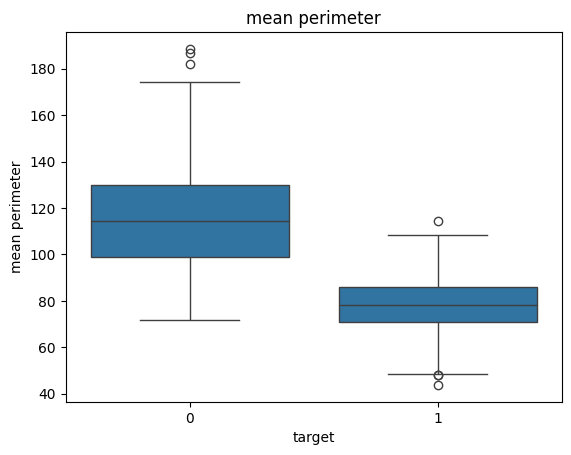

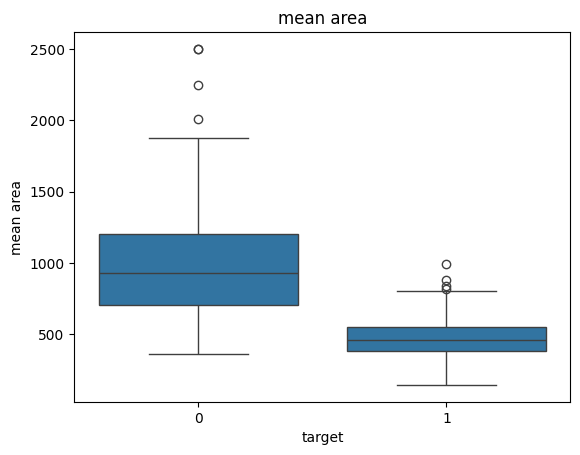

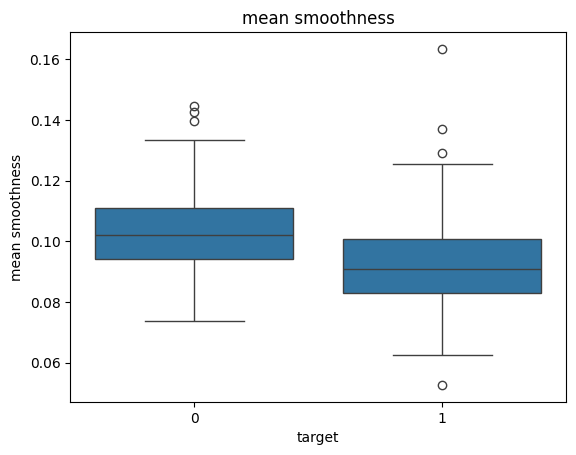

In [13]:
# ─── Boxplots: Feature Spread by Class ────────────────────────────────────
# First 6 'mean' features — most informative ones

features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness'
]
# now make a loop to plot the sns ,box plot
for f in features:
    sns.boxplot(x='target', y=f, data=df)
    plt.title(f)


    plt.show()

##  Section 3 — Preprocessing Pipeline

In [14]:
# ─── Split Features & Target ───────────────────────────────────────────────
X = df.drop('target', axis=1)                             # Features (30 columns)
y = df['target']                                      # Target (0=Malignant, 1=Benign)


#print their shapes
print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')


Features shape : (569, 30)
Target shape   : (569,)


In [15]:
# ─── Train / Test Split ────────────────────────────────────────────────────
# stratify=y ensures same class ratio in both sets _SPLIT 80 : 20 STRATIFY ON Y
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # For reproducibility
    stratify=y           # Keep class balance
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]} samples')


Training set  : 455 samples
Test set      : 114 samples


In [47]:
# if we have class imbalance how to handle it ?  U can use smote

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [48]:
# Now very important step

# ─── Feature Scaling (StandardScaler) ─────────────────────────────────────
# WHY: Most ML/DL models work better when features are on the same scale
# IMPORTANT: Fit on train ONLY — never fit on test (data leakage!)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # Fit + Transform
X_test_scaled  = scaler.transform(X_test)         # Transform only (use train stats)



#after print these and check the data
print(' Scaling done!')
print(f'Mean before scaling (first feature): {X_train.iloc[:,0].mean():.2f}')
print(f'Mean after  scaling (first feature): {X_train_scaled[:,0].mean():.4f}')
print(f'Std  after  scaling (first feature): {X_train_scaled[:,0].std():.4f}')



 Scaling done!
Mean before scaling (first feature): 14.72
Mean after  scaling (first feature): -0.0000
Std  after  scaling (first feature): 1.0000


---
##  Section 4 — ML Models Training & Evaluation

In [60]:

# Step 1: Define the models we want to try
# We store them in a dictionary so we can loop over them easily
# Key = model name (for printing)
# Value = actual model object



ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "KNN": KNeighborsClassifier()
}



In [61]:
# Step 2: Create a function to TRAIN all models
# This function will:
# 1. Loop over each model
# 2. Train (fit) the model on training data
# 3. Store the trained model in a new dictionary
# 4. Return all trained models

def train_models(models, X_train, y_train):
    trained_models = {}

    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Save the trained model
        trained_models[name] = model

        # Print progress
        print(f"{name} trained successfully")

    return trained_models

In [62]:
# Step 3: Create a function to EVALUATE all models
# This function will:
# 1. Loop over trained models
# 2. Make predictions on test data
# 3. Calculate performance metrics Accuracy _ percision _ f1 score _ Classification report
# 4. Print results for each model
# 5. Store results in a list (for comparison later)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        # Make predictions
        y_pred = model.predict(X_test)

        # Calculate metrics
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)

        # Print results clearly
        print("=============================")
        print(f"Model: {name}")
        print("==============================")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        # Save results
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1
        })

    return results

In [63]:
#just call them
# Step 4: Train all models
trained_models = train_models(ml_models, X_train, y_train)

# Step 5: Evaluate all models
results = evaluate_models(trained_models, X_test, y_test)

Logistic Regression trained successfully
Random Forest trained successfully
SVM trained successfully
XGBoost trained successfully
KNN trained successfully
Model: Logistic Regression
Accuracy : 0.9649
Precision: 0.9722
Recall   : 0.9722
F1 Score : 0.9722

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

Model: Random Forest
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weight

In [64]:
# Step 6: Convert results into a DataFrame for easy comparison


results_df = pd.DataFrame(results)

# Sort models by best METRIC
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.964912   0.972222  0.972222  0.972222
1        Random Forest  0.956140   0.958904  0.972222  0.965517
3              XGBoost  0.947368   0.945946  0.972222  0.958904
4                  KNN  0.912281   0.942857  0.916667  0.929577
2                  SVM  0.903509   0.929577  0.916667  0.923077


In [65]:
#NOW CHOOSE THE BEST MODEL U WANT TO CHOOSE FOR DEPLOYMENT
best_model = trained_models["Logistic Regression"]

In [66]:
#SAVE THE MODEL AND THE SCALER

import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# let's create a simple prediction function




In [67]:
#takes an input _ return  Bengin if pred == 1 or Malignant if 0


def predict(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    input_scaled = scaler.transform(input_data)

    pred = best_model.predict(input_scaled)[0]

    if pred == 1:
        return "Benign"
    else:
        return "Malignant"

In [68]:
sample_row = [
    19.81, 22.15, 130, 1260, 0.09831, 0.1027, 0.1479, 0.09498, 0.1582, 0.05395,
    0.7582, 1.017, 5.865, 112.4, 0.006494, 0.01893, 0.03391, 0.01521, 0.01356,
    0.001997, 27.32, 30.88, 186.8, 2398, 0.1512, 0.315, 0.5372, 0.2388, 0.2768,
    0.07615, 0   # ده target (نشيله في الاختبار)
]

In [ ]:
#

In [69]:
sample_input = sample_row[:-1]

In [70]:
print(predict(sample_input))

Benign


In [72]:
# we can take any sample that has benign class
benign_sample = df[df["target"] == 1].sample(1).drop("target", axis=1).values[0]
print(predict(benign_sample))

Benign



## Section 5 — Deep Learning (ANN & DNN)


In [74]:


# ─── Build Simple ANN ─────────────────────────────────────────
# A basic neural network (good baseline)

def build_ann(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')   # Binary classification
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# ─── Build Deep Neural Network (DNN) ──────────────────────────
# More complex model with regularization

def build_dnn(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dropout(0.1),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# ─── Initialize Models ────────────────────────────────────────
ann_model = build_ann(X_train_scaled.shape[1])
dnn_model = build_dnn(X_train_scaled.shape[1])

print("ANN & DNN models created!")


# ─── Early Stopping ───────────────────────────────────────────
# Stops training when validation stops improving

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


# ─── Train ANN ────────────────────────────────────────────────
print("Training ANN...")

history_ann = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("ANN training finished!")


# ─── Train DNN ────────────────────────────────────────────────
print("Training DNN...")

history_dnn = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("DNN training finished!")


# ─── Evaluation Function for DL Models ────────────────────────

def evaluate_dl(model, X_test, y_test):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    return acc, prec, rec, f1


# ─── Evaluate ANN & DNN ───────────────────────────────────────

ann_acc, ann_prec, ann_rec, ann_f1 = evaluate_dl(ann_model, X_test_scaled, y_test)
dnn_acc, dnn_prec, dnn_rec, dnn_f1 = evaluate_dl(dnn_model, X_test_scaled, y_test)

print("\nANN Results:")
print(f"Accuracy : {ann_acc:.4f}")
print(f"Precision: {ann_prec:.4f}")
print(f"Recall   : {ann_rec:.4f}")
print(f"F1 Score : {ann_f1:.4f}")

print("\nDNN Results:")
print(f"Accuracy : {dnn_acc:.4f}")
print(f"Precision: {dnn_prec:.4f}")
print(f"Recall   : {dnn_rec:.4f}")
print(f"F1 Score : {dnn_f1:.4f}")


# ─── Compare ML vs DL ─────────────────────────────────────────

dl_results = pd.DataFrame([
    {"Model": "ANN", "Accuracy": ann_acc, "Precision": ann_prec, "Recall": ann_rec, "F1 Score": ann_f1},
    {"Model": "DNN", "Accuracy": dnn_acc, "Precision": dnn_prec, "Recall": dnn_rec, "F1 Score": dnn_f1}
])

# Combine with previous ML results
final_results = pd.concat([results_df, dl_results], ignore_index=True)

# Sort by best Accuracy
final_results = final_results.sort_values(by="Accuracy", ascending=False)

print("\nFinal Comparison (ML vs DL):")
print(final_results)


# ─── Select Best Model Automatically ──────────────────────────

best_model_name = final_results.iloc[0]["Model"]
print(f"\nBest Model: {best_model_name}")


# ─── Save Best Model ──────────────────────────────────────────

if best_model_name in trained_models:
    # ML model
    best_model = trained_models[best_model_name]
    joblib.dump(best_model, "best_model.pkl")
    print("Best ML model saved!")

elif best_model_name == "ANN":
    ann_model.save("best_model.h5")
    print("ANN model saved!")

else:
    dnn_model.save("best_model.h5")
    print("DNN model saved!")

ANN & DNN models created!
Training ANN...
ANN training finished!
Training DNN...
DNN training finished!
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

ANN Results:
Accuracy : 0.9474
Precision: 0.9853
Recall   : 0.9306
F1 Score : 0.9571

DNN Results:
Accuracy : 0.9211
Precision: 0.8889
Recall   : 1.0000
F1 Score : 0.9412

Final Comparison (ML vs DL):
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.964912   0.972222  0.972222  0.972222
1        Random Forest  0.956140   0.958904  0.972222  0.965517
2              XGBoost  0.947368   0.945946  0.972222  0.958904
5                  ANN  0.947368   0.985294  0.930556  0.957143
6                  DNN  0.921053   0.888889  1.000000  0.941176
3                  KNN  0.912281   0.942857  0.916667  0.929577
4                  SVM  0.903509   0.929577  0.916667  0.923077

Best Model: Logistic Regression
Best ML model saved!
